<a href="https://colab.research.google.com/github/zakari90/-DataAnalysis/blob/main/client_behavior_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/content/drive/MyDrive/hsoub ai/customer_behaviour.csv", delimiter=(";"))
df

,account length,location code,user id,credit card info save,push status,add to wishlist,desktop sessions,app sessions,desktop transactions,total product detail views,session duration,promotion clicks,avg order value,sale product views,discount rate per visited products,product detail view per app session,app transactions,add to cart per session,customer service calls,churn
0,128,415,3824657,no,yes,25,265,45,17,110,197,87,"244,7",91,"11,01",10,3,"2,7",1,0
1,107,415,3717191,no,yes,26,162,27,17,123,196,103,"254,4",103,"11,45","13,7",3,"3,7",1,0
2,137,415,3581921,no,no,0,243,41,10,114,121,110,"162,6",104,"7,32","12,2",5,"3,29",0,0
3,84,408,3759999,yes,no,0,299,51,5,71,62,88,"196,9",89,"8,86","6,6",7,"1,78",2,0
4,75,415,3306626,yes,no,0,167,28,13,113,148,122,"186,9",121,"8,41","10,1",3,"2,73",3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,415,4144276,no,yes,36,156,27,18,77,216,126,"279,1",83,"12,56","9,9",6,"2,67",2,0
3329,68,415,3703271,no,no,0,231,39,13,57,153,55,"191,3",123,"8,61","9,6",4,"2,59",3,0
3330,28,510,3288230,no,no,0,181,31,25,109,289,58,"191,9",91,"8,64","14,1",6,"3,81",2,0
3331,184,510,3646381,yes,no,0,214,36,14,105,160,84,"139,2",137,"6,26",5,10,"1,35",2,0


In [9]:
df.columns

Index(['account length', 'location code', 'user id', 'credit card info save',
       'push status', 'add to wishlist', 'desktop sessions', 'app sessions',
       'desktop transactions', 'total product detail views',
       'session duration', 'promotion clicks', 'avg order value',
       'sale product views', 'discount rate per visited products',
       'product detail view per app session', 'app transactions',
       'add to cart per session', 'customer service calls', 'churn'],
      dtype='object')

In [10]:
df.columns =  df.columns.str.replace(" ", "_")
df.columns

Index(['account_length', 'location_code', 'user_id', 'credit_card_info_save',
       'push_status', 'add_to_wishlist', 'desktop_sessions', 'app_sessions',
       'desktop_transactions', 'total_product_detail_views',
       'session_duration', 'promotion_clicks', 'avg_order_value',
       'sale_product_views', 'discount_rate_per_visited_products',
       'product_detail_view_per_app_session', 'app_transactions',
       'add_to_cart_per_session', 'customer_service_calls', 'churn'],
      dtype='object')

In [11]:
df['avg_order_value'] = df['avg_order_value'].replace(',','.', regex=True).astype(float)
df['discount_rate_per_visited_products'] = df['discount_rate_per_visited_products'].replace(',','.', regex=True).astype(float)
df['add_to_cart_per_session'] = df['add_to_cart_per_session'].replace(',','.', regex=True).astype(float)
df['product_detail_view_per_app_session'] = df['product_detail_view_per_app_session'].replace(',','.', regex=True).astype(float)

df.dtypes

,0
account_length,int64
location_code,int64
user_id,int64
credit_card_info_save,object
push_status,object
add_to_wishlist,int64
desktop_sessions,int64
app_sessions,int64
desktop_transactions,int64
total_product_detail_views,int64


In [12]:
df.describe()

,account_length,location_code,user_id,add_to_wishlist,desktop_sessions,app_sessions,desktop_transactions,total_product_detail_views,session_duration,promotion_clicks,avg_order_value,sale_product_views,discount_rate_per_visited_products,product_detail_view_per_app_session,app_transactions,add_to_cart_per_session,customer_service_calls,churn
count,3333.000000,3333.000000,3.333000e+03,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,3.746291e+06,8.099010,179.811881,30.567957,17.087609,100.435644,201.039604,100.110711,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856,0.144914
std,39.822106,42.371290,2.746626e+05,13.688365,54.457135,9.269376,4.323795,20.069084,50.714359,19.923911,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491,0.352067
min,1.000000,408.000000,3.271058e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,3.508680e+06,0.000000,144.000000,24.000000,14.000000,87.000000,167.000000,87.000000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000,0.000000
50%,101.000000,415.000000,3.748187e+06,0.000000,179.000000,31.000000,17.000000,101.000000,201.000000,100.000000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000,0.000000
75%,127.000000,510.000000,3.985970e+06,20.000000,216.000000,37.000000,20.000000,114.000000,235.000000,114.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000,0.000000
max,243.000000,510.000000,4.229964e+06,51.000000,351.000000,60.000000,31.000000,165.000000,364.000000,170.000000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


In [13]:
df.describe(exclude= ['int', 'float'])

,credit_card_info_save,push_status
count,3333,3333
unique,2,2
top,no,no
freq,3010,2411


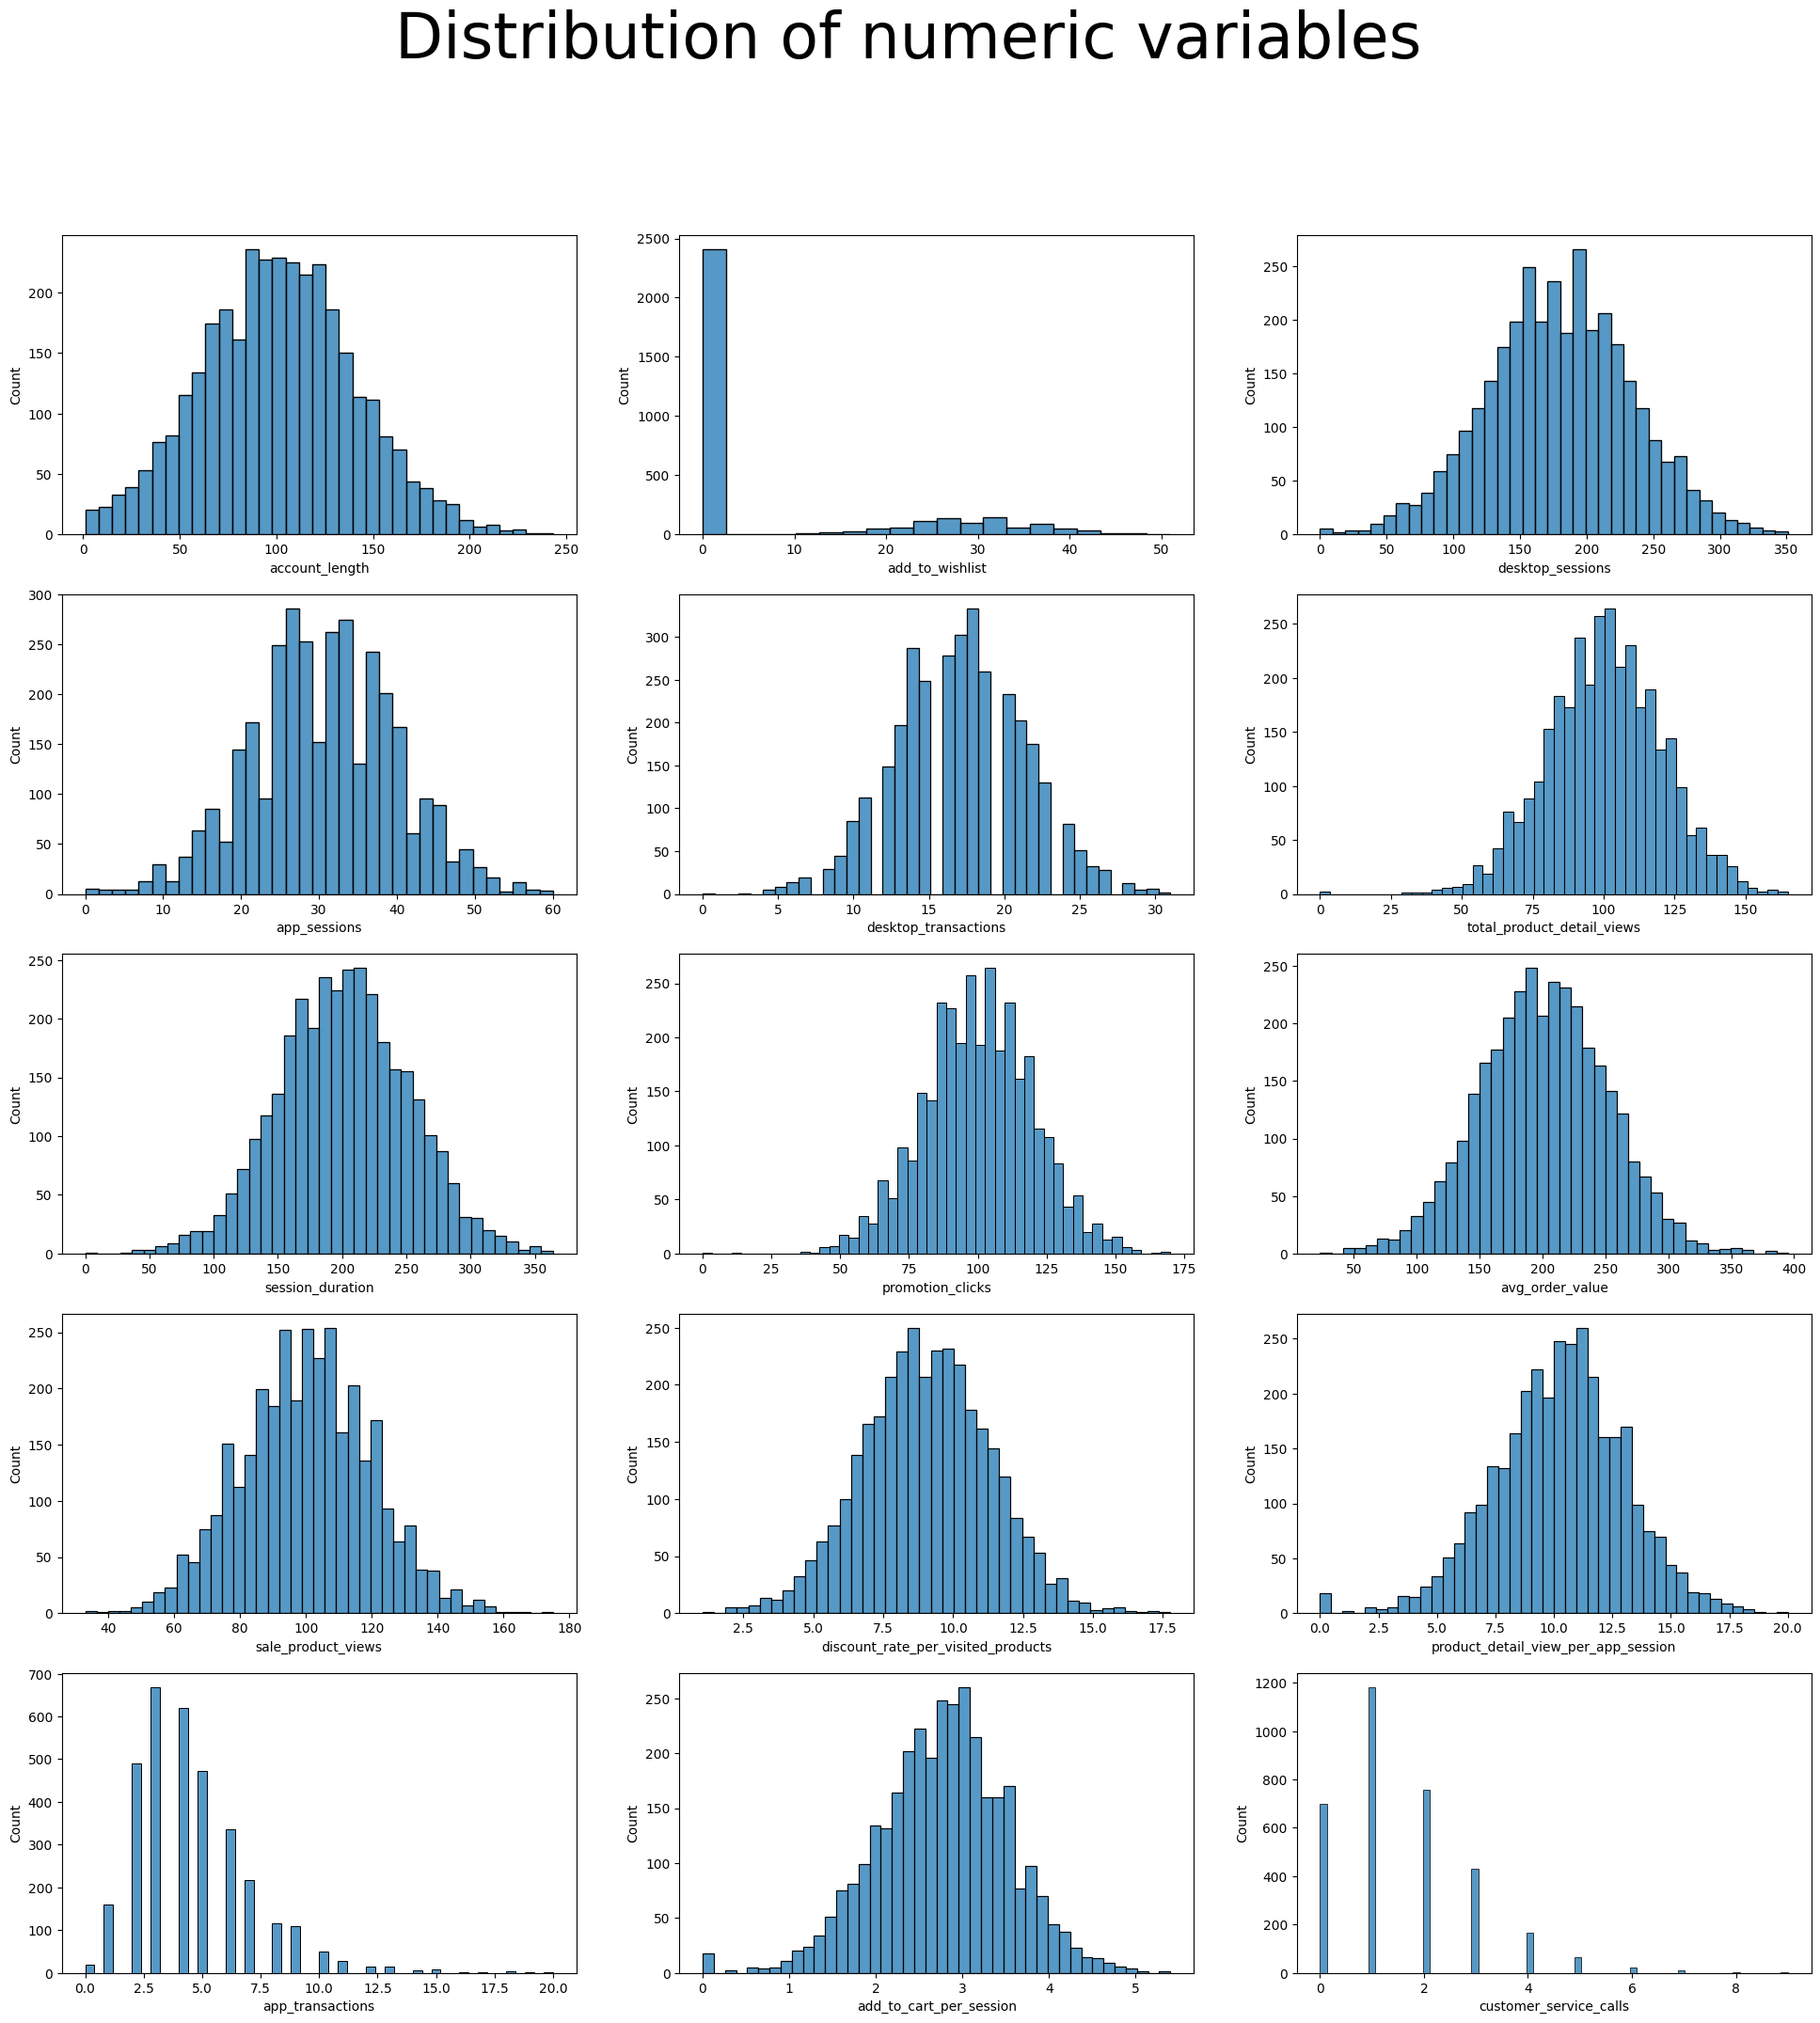

In [14]:
numeric_columns = ['account_length', 'add_to_wishlist', 'desktop_sessions','app_sessions', 'desktop_transactions',
                   'total_product_detail_views','session_duration', 'promotion_clicks', 'avg_order_value','sale_product_views',
                   'discount_rate_per_visited_products','product_detail_view_per_app_session', 'app_transactions',
                   'add_to_cart_per_session', 'customer_service_calls']

fig, axes = plt.subplots(5,3, figsize=(24,24))
fig.suptitle("Distribution of numeric variables", size=48)

for i in range(5):
    for j in range(3):
        sns.histplot(df[numeric_columns[3*i+j]], ax=axes[i,j])

In [15]:
df.churn.value_counts()

,count
churn,
0,2850
1,483


/tmp/ipykernel_2081/1200351380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cp = sns.countplot(x= df['churn'], ax = ax[0], palette = 'husl')


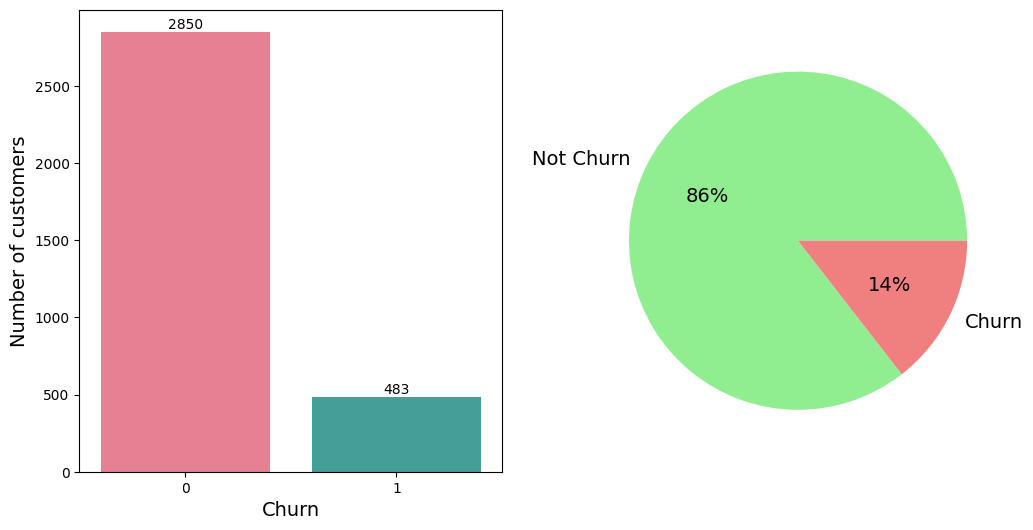

In [34]:
fig, ax = plt.subplots(1,2,figsize= (12,6))

plt.pie(df.churn.value_counts(), labels = ["Not Churn", "Churn"], colors = ["lightgreen", "lightcoral"], autopct='%.0f%%', textprops={'fontsize': 14})

cp = sns.countplot(x= df['churn'], ax = ax[0], palette = 'husl')
cp.bar_label(cp.containers[0])
cp.bar_label(cp.containers[1])

cp.set_xlabel("Churn", fontsize=14)

cp.set_ylabel("Number of customers", fontsize=14)
plt.show()

To correctly add labels to the bars in your count plot, you need to call `bar_label` on the `Axes` object that contains the plot. In the previous cell, `sns.countplot` returned an `Axes` object which you assigned to the variable `cp`.

/tmp/ipykernel_2081/1007086536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cp = sns.countplot(x= df['churn'], ax = ax[0], palette = 'husl')


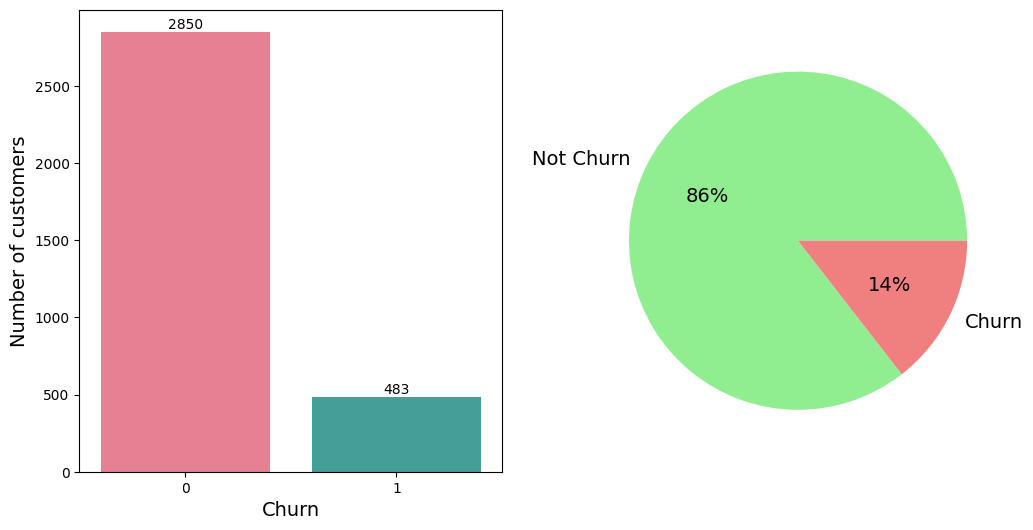

In [33]:
fig, ax = plt.subplots(1,2,figsize= (12,6))

plt.pie(df.churn.value_counts(), labels = ["Not Churn", "Churn"], colors = ["lightgreen", "lightcoral"], autopct='%.0f%%', textprops={'fontsize': 14})

cp = sns.countplot(x= df['churn'], ax = ax[0], palette = 'husl')

# Add labels to the bars
cp.bar_label(cp.containers[0])
cp.bar_label(cp.containers[1])

cp.set_xlabel("Churn", fontsize=14)

cp.set_ylabel("Number of customers", fontsize=14)
plt.show()

/tmp/ipykernel_2081/4042274203.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[i] = df[i].replace(["yes", "no"],[1, 0])


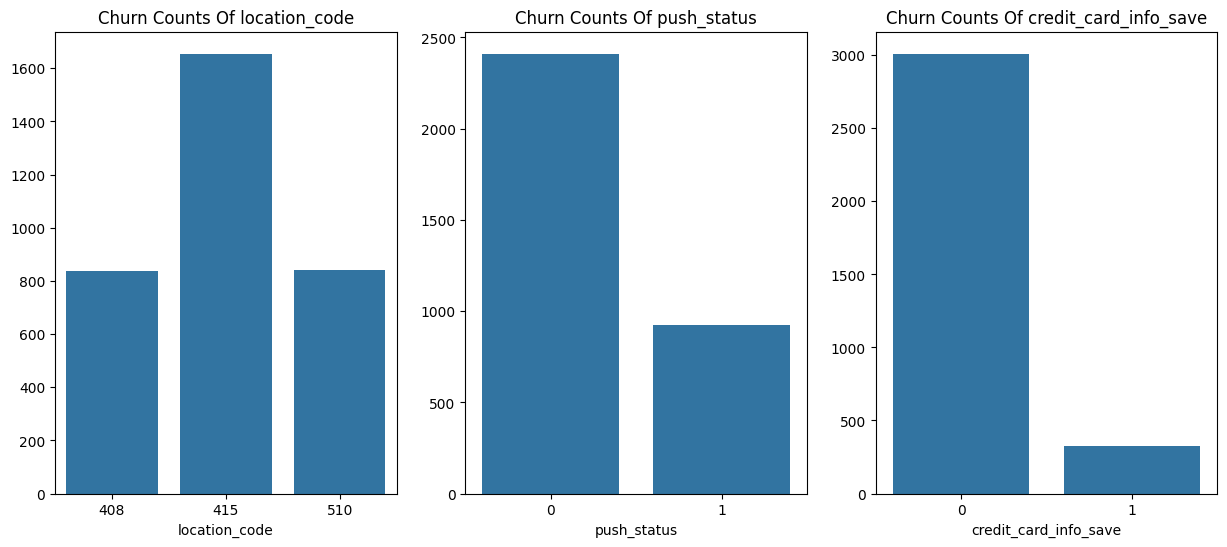

In [35]:
categorical_columns = ["location_code","push_status","credit_card_info_save"]

for i in df.select_dtypes(include = ['object']).columns.values:
    df[i] = df[i].replace(["yes", "no"],[1, 0])

fig, ax = plt.subplots(1, len(categorical_columns), figsize = (15, 6))
for i, a in zip(categorical_columns, ax):
    temp = df[i].value_counts()
    a.set_title("Churn Counts Of " + str(i))
    sns.barplot(ax = a, x=temp.index, y=temp.values)
plt.show()